In [117]:
# Standard libraries
import os
import json
from pathlib import Path

# Numerical & image processing
import numpy as np
import cv2
import tifffile as tiff

# Visualization
import matplotlib.pyplot as plt

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader

# Torchvision (Mask R-CNN)
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.transforms import functional as F

# Utils
from tqdm import tqdm

from pycocotools import mask as mask_utils

# VARIABLES GLOBALES

In [89]:
# TODO: adapt this path to your dataset location
DATA_DIR = Path("hw3-data-release")

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test_release"
TEST_MAPPING_PATH = DATA_DIR / "test_image_name_to_ids.json"

NUM_EPOCHS = 15

CLASS_FILES = {
    1: "class1.tif",
    2: "class2.tif",
    3: "class3.tif",
    4: "class4.tif",
}

# PARTIE 1

In [90]:
def read_tif(path):
    """Read a .tif image or mask."""
    return tiff.imread(str(path))


def extract_instances_from_class_mask(class_mask, class_id):
    """
    Extract binary instance masks from one class mask.

    Each non-zero unique value corresponds to one instance.
    Background is value 0.
    """
    instances = []

    instance_ids = np.unique(class_mask)
    instance_ids = instance_ids[instance_ids != 0]

    for instance_id in instance_ids:
        binary_mask = (class_mask == instance_id).astype(np.uint8)

        instances.append({
            "class_id": class_id,
            "instance_id": int(instance_id),
            "mask": binary_mask,
        })

    return instances


def load_training_sample(sample_dir):
    """
    Load one training sample:
    - raw image
    - all instance masks
    - class labels
    """
    sample_dir = Path(sample_dir)

    image_path = sample_dir / "image.tif"
    image = read_tif(image_path)

    all_instances = []

    for class_id, class_file in CLASS_FILES.items():
        mask_path = sample_dir / class_file

        if not mask_path.exists():
            continue

        class_mask = read_tif(mask_path)
        class_instances = extract_instances_from_class_mask(
            class_mask,
            class_id
        )
        all_instances.extend(class_instances)

    return image, all_instances

In [91]:
sample_dirs = sorted([p for p in TRAIN_DIR.iterdir() if p.is_dir()])

sample_dir = sample_dirs[0]
image, instances = load_training_sample(sample_dir)

print("Sample:", sample_dir.name)
print("Image shape:", image.shape)
print("Number of instances:", len(instances))

for instance in instances:
    print(
        "Class:",
        instance["class_id"],
        "| Instance ID:",
        instance["instance_id"],
        "| Mask shape:",
        instance["mask"].shape,
        "| Pixels:",
        instance["mask"].sum()
    )

Sample: 0088d6cd-fcbd-4037-babf-74abd3c82204
Image shape: (560, 600, 4)
Number of instances: 131
Class: 1 | Instance ID: 1 | Mask shape: (560, 600) | Pixels: 362
Class: 1 | Instance ID: 2 | Mask shape: (560, 600) | Pixels: 155
Class: 1 | Instance ID: 3 | Mask shape: (560, 600) | Pixels: 177
Class: 1 | Instance ID: 4 | Mask shape: (560, 600) | Pixels: 285
Class: 1 | Instance ID: 5 | Mask shape: (560, 600) | Pixels: 318
Class: 1 | Instance ID: 6 | Mask shape: (560, 600) | Pixels: 568
Class: 1 | Instance ID: 7 | Mask shape: (560, 600) | Pixels: 653
Class: 1 | Instance ID: 8 | Mask shape: (560, 600) | Pixels: 527
Class: 1 | Instance ID: 9 | Mask shape: (560, 600) | Pixels: 293
Class: 1 | Instance ID: 10 | Mask shape: (560, 600) | Pixels: 646
Class: 1 | Instance ID: 11 | Mask shape: (560, 600) | Pixels: 368
Class: 1 | Instance ID: 12 | Mask shape: (560, 600) | Pixels: 639
Class: 1 | Instance ID: 13 | Mask shape: (560, 600) | Pixels: 475
Class: 1 | Instance ID: 14 | Mask shape: (560, 600) | 

In [92]:
def get_bounding_box(mask):
    """
    Compute bounding box from binary mask.
    Format: [xmin, ymin, xmax, ymax]
    """
    ys, xs = np.where(mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return None

    xmin = xs.min()
    xmax = xs.max()
    ymin = ys.min()
    ymax = ys.max()

    return [xmin, ymin, xmax, ymax]


def enrich_instances(instances):
    """
    Add bounding boxes to each instance
    """
    enriched = []

    for inst in instances:
        bbox = get_bounding_box(inst["mask"])

        if bbox is None:
            continue

        inst["bbox"] = bbox
        enriched.append(inst)

    return enriched

In [93]:
def prepare_target(instances):
    """
    Convert instances into model-ready format
    (Mask R-CNN style)
    """
    masks = []
    labels = []
    boxes = []

    for inst in instances:
        masks.append(inst["mask"])
        labels.append(inst["class_id"])
        boxes.append(inst["bbox"])

    masks = np.stack(masks) if len(masks) > 0 else np.zeros((0,))
    labels = np.array(labels)
    boxes = np.array(boxes)

    return {
        "masks": masks,
        "labels": labels,
        "boxes": boxes
    }

In [94]:
image, instances = load_training_sample(sample_dir)

instances = enrich_instances(instances)
target = prepare_target(instances)

print("Image shape:", image.shape)
print("Masks shape:", target["masks"].shape)
print("Labels shape:", target["labels"].shape)
print("Boxes shape:", target["boxes"].shape)

Image shape: (560, 600, 4)
Masks shape: (131, 560, 600)
Labels shape: (131,)
Boxes shape: (131, 4)


# PARTIE 2

In [95]:
class CellInstanceDataset(torch.utils.data.Dataset):
    """
    PyTorch dataset for HW3 instance segmentation.

    Each item returns:
    - image: Tensor [C, H, W]
    - target: dict with boxes, labels, masks, image_id, area, iscrowd
    """

    def __init__(self, train_dir, transforms=None):
        self.train_dir = Path(train_dir)
        self.transforms = transforms

        self.sample_dirs = sorted([
            p for p in self.train_dir.iterdir()
            if p.is_dir()
        ])

    def __len__(self):
        return len(self.sample_dirs)

    def __getitem__(self, idx):
        sample_dir = self.sample_dirs[idx]

        image, instances = load_training_sample(sample_dir)
        instances = enrich_instances(instances)

        image = self._prepare_image(image)

        boxes = []
        labels = []
        masks = []

        for inst in instances:
            boxes.append(inst["bbox"])
            labels.append(inst["class_id"])
            masks.append(inst["mask"])

        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            masks = torch.as_tensor(np.array(masks), dtype=torch.uint8)

            area = (boxes[:, 2] - boxes[:, 0]) * (
                boxes[:, 3] - boxes[:, 1]
            )
            iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            masks = torch.zeros(
                (0, image.shape[1], image.shape[2]),
                dtype=torch.uint8
            )
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": iscrowd,
        }

        if self.transforms is not None:
            image, target = self.transforms(image, target)

        return image, target

    def _prepare_image(self, image):
        """
        Convert image to tensor format [C, H, W] and normalize to [0, 1].
        """
        image = image.astype(np.float32)

        if image.max() > 1.0:
            image = image / 255.0

        if image.ndim == 2:
            image = np.stack([image, image, image], axis=-1)

        if image.shape[-1] == 4:
            image = image[:, :, :3]

        image = torch.from_numpy(image)
        image = image.permute(2, 0, 1)

        return image

In [96]:
def horizontal_flip(image, target, p=0.5):
    if torch.rand(1).item() < p:
        image = torch.flip(image, dims=[2])

        _, height, width = image.shape
        boxes = target["boxes"]

        xmin = width - boxes[:, 2]
        xmax = width - boxes[:, 0]

        boxes[:, 0] = xmin
        boxes[:, 2] = xmax

        target["boxes"] = boxes
        target["masks"] = torch.flip(target["masks"], dims=[2])

    return image, target


def vertical_flip(image, target, p=0.5):
    if torch.rand(1).item() < p:
        image = torch.flip(image, dims=[1])

        _, height, width = image.shape
        boxes = target["boxes"]

        ymin = height - boxes[:, 3]
        ymax = height - boxes[:, 1]

        boxes[:, 1] = ymin
        boxes[:, 3] = ymax

        target["boxes"] = boxes
        target["masks"] = torch.flip(target["masks"], dims=[1])

    return image, target


def train_transforms(image, target):
    image, target = horizontal_flip(image, target, p=0.5)
    image, target = vertical_flip(image, target, p=0.5)

    return image, target

In [97]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [98]:
dataset = CellInstanceDataset(TRAIN_DIR, transforms=train_transforms)

num_samples = len(dataset)
indices = torch.randperm(num_samples).tolist()

val_ratio = 0.15
val_size = int(num_samples * val_ratio)

val_indices = indices[:val_size]
train_indices = indices[val_size:]

train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset = torch.utils.data.Subset(dataset, val_indices)

print("Total samples:", num_samples)
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Total samples: 209
Train samples: 178
Validation samples: 31


In [99]:
BATCH_SIZE = 2
NUM_WORKERS = 0

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

In [100]:
images, targets = next(iter(train_loader))

print("Number of images in batch:", len(images))
print("Image shape:", images[0].shape)

print("Target keys:", targets[0].keys())
print("Boxes shape:", targets[0]["boxes"].shape)
print("Labels shape:", targets[0]["labels"].shape)
print("Masks shape:", targets[0]["masks"].shape)
print("Areas shape:", targets[0]["area"].shape)
print("Iscrowd shape:", targets[0]["iscrowd"].shape)

Number of images in batch: 2
Image shape: torch.Size([3, 1311, 1449])
Target keys: dict_keys(['boxes', 'labels', 'masks', 'image_id', 'area', 'iscrowd'])
Boxes shape: torch.Size([254, 4])
Labels shape: torch.Size([254])
Masks shape: torch.Size([254, 1311, 1449])
Areas shape: torch.Size([254])
Iscrowd shape: torch.Size([254])


# PARTIE 3

In [101]:
NUM_CLASSES = 5
# 0 = background
# 1 = class1
# 2 = class2
# 3 = class3
# 4 = class4

def get_model(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(
        weights="DEFAULT"
    )

    in_features_box = model.roi_heads.box_predictor.cls_score.in_features

    model.roi_heads.box_predictor = (
        torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
            in_features_box,
            num_classes
        )
    )

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256

    model.roi_heads.mask_predictor = (
        torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
            in_features_mask,
            hidden_layer,
            num_classes
        )
    )

    return model

In [102]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = get_model(NUM_CLASSES)
model.to(device)

print("Using device:", device)

Using device: cuda


In [103]:
LEARNING_RATE = 0.004
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005

params = [
    p for p in model.parameters()
    if p.requires_grad
]

optimizer = torch.optim.SGD(
    params,
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=0.00001
)

In [104]:
def train_one_epoch(model, optimizer, data_loader, device):
    model.train()

    total_loss = 0.0

    for images, targets in tqdm(data_loader):
        images = [
            image.to(device)
            for image in images
        ]

        targets = [
            {
                key: value.to(device)
                for key, value in target.items()
            }
            for target in targets
        ]

        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    avg_loss = total_loss / len(data_loader)

    return avg_loss

In [105]:
def validate_one_epoch(model, data_loader, device):
    model.train()

    total_loss = 0.0

    with torch.no_grad():
        for images, targets in tqdm(data_loader):
            images = [
                image.to(device)
                for image in images
            ]

            targets = [
                {
                    key: value.to(device)
                    for key, value in target.items()
                }
                for target in targets
            ]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            total_loss += losses.item()

    avg_loss = total_loss / len(data_loader)

    return avg_loss

In [106]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_path = "best_maskrcnn_hw3.pth"

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")

    train_loss = train_one_epoch(
        model,
        optimizer,
        train_loader,
        device
    )

    val_loss = validate_one_epoch(
        model,
        val_loader,
        device
    )

    lr_scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss:   {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("Best model saved.")


Epoch [1/15]


100%|██████████| 16/16 [00:49<00:00,  3.10s/it]


Train loss: 1.6657
Val loss:   1.2687
Best model saved.

Epoch [2/15]


100%|██████████| 16/16 [00:42<00:00,  2.65s/it]


Train loss: 1.1335
Val loss:   1.0934
Best model saved.

Epoch [3/15]


...

Train loss: 0.6991
Val loss:   0.8079

Epoch [14/15]


100%|██████████| 16/16 [00:31<00:00,  1.97s/it]


Train loss: 0.6801
Val loss:   0.8102

Epoch [15/15]


100%|██████████| 16/16 [00:33<00:00,  2.10s/it]


Train loss: 0.6798
Val loss:   0.7911
Best model saved.


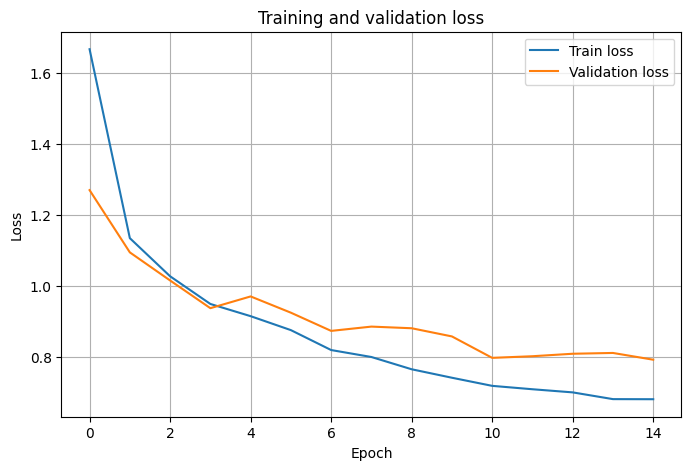

In [107]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)

plt.show()

# PARTIE 5 inferences

In [108]:
best_model_path = "best_hw3_079.pth"

In [109]:
model = get_model(NUM_CLASSES)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

print("Model loaded.")

Model loaded.


In [110]:
import json

with open(TEST_MAPPING_PATH, "r") as f:
    test_mapping = json.load(f)

print("Number of test images:", len(test_mapping))
print(test_mapping[0])

Number of test images: 101
{'file_name': 'c8cb7626-7423-4c1e-a81c-5ff25ea180b3.tif', 'id': 1, 'height': 446, 'width': 512}


In [111]:
def prepare_test_image(image_path):
    image = read_tif(image_path)

    image = image.astype(np.float32)

    if image.max() > 1.0:
        image = image / 255.0

    if image.ndim == 2:
        image = np.stack([image, image, image], axis=-1)

    if image.shape[-1] == 4:
        image = image[:, :, :3]

    image = torch.from_numpy(image).permute(2, 0, 1)

    return image

In [112]:
def predict_image(model, image_path, device):
    image = prepare_test_image(image_path)
    image = image.to(device)

    with torch.no_grad():
        prediction = model([image])[0]

    return prediction

In [113]:
all_predictions = []

for item in tqdm(test_mapping):
    file_name = item["file_name"]
    image_id = item["id"]

    image_path = TEST_DIR / file_name

    prediction = predict_image(model, image_path, device)

    all_predictions.append({
        "image_id": image_id,
        "file_name": file_name,
        "prediction": prediction
    })

print("Inference done.")

100%|██████████| 101/101 [02:47<00:00,  1.66s/it]

Inference done.


# PARTIE 6

In [114]:
MIN_SCORE = 0.5
MIN_MASK_AREA = 20
MASK_THRESHOLD = 0.5


def filter_prediction(prediction):
    """
    Filter predictions using score and mask area.

    This removes low-confidence detections and tiny noisy masks.
    """
    filtered = []

    scores = prediction["scores"].detach().cpu()
    labels = prediction["labels"].detach().cpu()
    masks = prediction["masks"].detach().cpu()

    for i in range(len(scores)):
        score = scores[i].item()

        if score < MIN_SCORE:
            continue

        label = labels[i].item()

        mask = masks[i, 0]
        binary_mask = mask > MASK_THRESHOLD

        mask_area = binary_mask.sum().item()

        if mask_area < MIN_MASK_AREA:
            continue

        filtered.append({
            "label": int(label),
            "score": float(score),
            "mask": binary_mask.numpy().astype(np.uint8),
        })

    return filtered

In [118]:
def encode_binary_mask_to_rle(binary_mask):
    """
    Convert a binary mask to COCO RLE format.
    """
    binary_mask = np.asfortranarray(binary_mask.astype(np.uint8))

    rle = mask_utils.encode(binary_mask)

    rle["counts"] = rle["counts"].decode("utf-8")

    return rle

In [119]:
def prediction_to_submission_items(image_id, prediction):
    """
    Convert model prediction for one image into submission format.
    """
    submission_items = []

    filtered_predictions = filter_prediction(prediction)

    for pred in filtered_predictions:
        rle = encode_binary_mask_to_rle(pred["mask"])

        submission_items.append({
            "image_id": int(image_id),
            "category_id": int(pred["label"]),
            "segmentation": rle,
            "score": float(pred["score"]),
        })

    return submission_items

In [120]:
submission_results = []

for item in tqdm(all_predictions):
    image_id = item["image_id"]
    prediction = item["prediction"]

    image_results = prediction_to_submission_items(
        image_id,
        prediction
    )

    submission_results.extend(image_results)

print("Number of predictions:", len(submission_results))
print(submission_results[0])

100%|██████████| 101/101 [00:44<00:00,  2.27it/s]

Number of predictions: 5804
{'image_id': 1, 'category_id': 1, 'segmentation': {'size': [446, 512], 'counts': 'Xle35e=8J3N2N3M2N1O2O00001O00001O00000001O000O2O1N1O2O2M3K6Laml2'}, 'score': 0.9926071166992188}


In [121]:
output_path = "test-results.json"

with open(output_path, "w") as f:
    json.dump(submission_results, f)

print("Submission file saved:", output_path)

Submission file saved: test-results.json
